In [3]:
import pandas as pd

import sys
sys.path.append("..")

In [9]:
from config import POPULATION_SECTEUR_PATH

population_secteur_raw = pd.read_csv(POPULATION_SECTEUR_PATH,      sep="|",     encoding='latin1'  )

display(population_secteur_raw)



,CD_REFNIS,CD_SECTOR,TOTAL,DT_STRT_SECTOR,DT_STOP_SECTOR,OPPERVLAKKTE IN HM²,TX_DESCR_SECTOR_NL,TX_DESCR_SECTOR_FR,TX_DESCR_NL,TX_DESCR_FR
0,11001,11001A00-,2618,01/03/1981,31/12/9999,"52,9876523968054",AARTSELAAR-CENTRUM,AARTSELAAR-CENTRUM,Aartselaar,Aartselaar
1,11001,11001A01-,2922,01/03/1981,31/12/9999,"67,2440779981788",DE LEEUWERIK,DE LEEUWERIK,Aartselaar,Aartselaar
2,11001,11001A020,763,01/03/1981,31/12/9999,"28,0836525518644",BUERSTEDE,BUERSTEDE,Aartselaar,Aartselaar
3,11001,11001A030,487,01/03/1981,31/12/9999,"42,8105162953392",YSSELAAR,YSSELAAR,Aartselaar,Aartselaar
4,11001,11001A042,354,01/03/1981,31/12/9999,"25,4857858896115",KLEINE GRIPPE,KLEINE GRIPPE,Aartselaar,Aartselaar
...,...,...,...,...,...,...,...,...,...,...
21178,93090,93090G191,30,01/03/1981,31/12/9999,"1509,55974083031",BOIS DE NISMES,BOIS DE NISMES,Viroinval,Viroinval
21179,93090,93090H000,226,01/03/1981,31/12/9999,"19,3882473007889",DOURBES-CENTRE,DOURBES-CENTRE,Viroinval,Viroinval
21180,93090,93090H012,71,01/03/1981,31/12/9999,"19,364186079601",DOURBES ROUTE DE MARIEMBOURG,DOURBES ROUTE DE MARIEMBOURG,Viroinval,Viroinval
21181,93090,93090H063,20,01/03/1981,31/12/9999,"24,8654600852495",LORET,LORET,Viroinval,Viroinval


In [11]:
list(population_secteur_raw.columns)

['CD_REFNIS',
 'CD_SECTOR',
 'TOTAL',
 'DT_STRT_SECTOR',
 'DT_STOP_SECTOR',
 'OPPERVLAKKTE IN HM²',
 'TX_DESCR_SECTOR_NL',
 'TX_DESCR_SECTOR_FR',
 'TX_DESCR_NL',
 'TX_DESCR_FR']

In [17]:
display(population_secteur_raw.shape)
population_secteur_raw.info()


(21183, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21183 entries, 0 to 21182
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CD_REFNIS            21183 non-null  int64 
 1   CD_SECTOR            21183 non-null  object
 2   TOTAL                21183 non-null  int64 
 3   DT_STRT_SECTOR       21183 non-null  object
 4   DT_STOP_SECTOR       21183 non-null  object
 5   OPPERVLAKKTE IN HM²  21183 non-null  object
 6   TX_DESCR_SECTOR_NL   21183 non-null  object
 7   TX_DESCR_SECTOR_FR   21183 non-null  object
 8   TX_DESCR_NL          21183 non-null  object
 9   TX_DESCR_FR          21183 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.6+ MB


In [22]:
population_secteur_raw.isna().sum()


CD_REFNIS              0
CD_SECTOR              0
TOTAL                  0
DT_STRT_SECTOR         0
DT_STOP_SECTOR         0
OPPERVLAKKTE IN HM²    0
TX_DESCR_SECTOR_NL     0
TX_DESCR_SECTOR_FR     0
TX_DESCR_NL            0
TX_DESCR_FR            0
dtype: int64

### TOTAL

- Présence de secteurs avec 0 habitant.
- À vérifier : zones industrielles, forêts, infrastructures ou secteurs non résidentiels.

## Observations

### OPPERVLAKKTE IN HM²

- La colonne est importée comme `object` et non comme `float`.
- Les décimales utilisent une virgule (`52,98`) au lieu d'un point (`52.98`).
- Une conversion sera nécessaire lors de la phase de transformation.

Action future :
- remplacer `,` par `.`
- convertir en type numérique (`float`)

'''
population_clean["surface_hm2"] = (
    population_clean["surface_hm2"]
    .str.replace(",", ".")
    .astype(float)
)
'''

In [26]:
display(population_secteur_raw[["OPPERVLAKKTE IN HM²"]].describe())
display(population_secteur_raw[["TOTAL"]].describe())

,OPPERVLAKKTE IN HM²
count,21183
unique,20782
top,0
freq,402


,TOTAL
count,21183.000000
mean,558.256668
std,697.022998
min,0.000000
25%,99.000000
50%,323.000000
75%,764.000000
max,9450.000000


In [24]:
population_secteur_raw[
    population_secteur_raw["TOTAL"] == 0
]

,CD_REFNIS,CD_SECTOR,TOTAL,DT_STRT_SECTOR,DT_STOP_SECTOR,OPPERVLAKKTE IN HM²,TX_DESCR_SECTOR_NL,TX_DESCR_SECTOR_FR,TX_DESCR_NL,TX_DESCR_FR
17,11002,1100212MQ,0,01/01/2025,31/12/9999,"81,0096675865386",STABROEK,STABROEK,Antwerpen,Anvers
24,11002,11002A08K,0,01/01/2025,31/12/9999,"5,33293547151026",NOORDELIJKE SCHELDEKADEN,NOORDELIJKE SCHELDEKADEN,Antwerpen,Anvers
25,11002,11002A08L,0,01/01/2025,31/12/9999,"9,64967134893469",ZUIDELIJKE SCHELDEKADEN,ZUIDELIJKE SCHELDEKADEN,Antwerpen,Anvers
50,11002,11002C28-,0,01/01/2025,31/12/9999,"12,0053076260964",STATION - ZOO (STATIONSWIJK ),STATION - ZOO (STATIONSWIJK ),Antwerpen,Anvers
51,11002,11002C29-,0,01/01/2025,31/12/9999,"15,0690700390945",STADSPARK (STATIONSWIJK ),STADSPARK (STATIONSWIJK ),Antwerpen,Anvers
...,...,...,...,...,...,...,...,...,...,...
21101,93088,93088K09L,0,01/01/2025,31/12/9999,"193,621114786108",SOMZEE-HABITATIONS DISPERSEES EST,SOMZEE-HABITATIONS DISPERSEES EST,Walcourt,Walcourt
21136,93088,93088R264,0,01/03/1981,31/12/9999,"9,24821030349311",ROSETTE,ROSETTE,Walcourt,Walcourt
21143,93090,93090A063,0,01/03/1981,31/12/9999,"11,9707781359712",TRY DES BAUDETS,TRY DES BAUDETS,Viroinval,Viroinval
21166,93090,93090F06K,0,01/01/2025,31/12/9999,"18,836243530045",OIGNIES VILLAGE DE VACANCES,OIGNIES VILLAGE DE VACANCES,Viroinval,Viroinval


In [37]:
population_secteur_raw[
    population_secteur_raw["TX_DESCR_FR"] == "Liège"
].nunique()

CD_REFNIS                1
CD_SECTOR              218
TOTAL                  193
DT_STRT_SECTOR           3
DT_STOP_SECTOR           1
OPPERVLAKKTE IN HM²    218
TX_DESCR_SECTOR_NL     218
TX_DESCR_SECTOR_FR     218
TX_DESCR_NL              1
TX_DESCR_FR              1
dtype: int64

<Axes: >

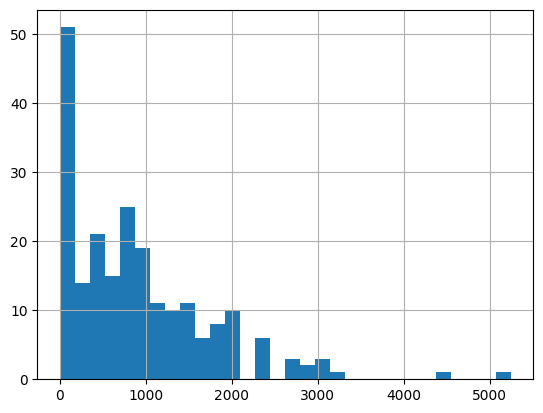

In [39]:
liege["TOTAL"].hist(bins=30)

In [42]:
liege.nlargest(10, "TOTAL")[
    ["TX_DESCR_SECTOR_FR", "TOTAL"]
]

,TX_DESCR_SECTOR_FR,TOTAL
14267,SAINTE-FOY,5246
14331,RESISTANCE,4528
14282,PUITS-EN-STOCK,3200
14246,LAVEU,3084
14284,CONGRES,3005
14266,SAINT-LEONARD,2998
14294,AMERCOEUR,2936
14257,SAINTE-WALBURGE,2854
14286,LONGDOZ,2743
14292,LUXEMBOURG,2682


In [43]:
liege.nsmallest(10, "TOTAL")[
    ["TX_DESCR_SECTOR_FR", "TOTAL"]
]

,TX_DESCR_SECTOR_FR,TOTAL
14238,PLAINE DE COINTE,0
14264,TERRIL BATTERIE NOUVEAU,0
14297,LIEGE EXPO,0
14307,BOIS DE WANDRE,0
14318,VERGERS DE POCHETEUX,0
14325,PARC DE FAYNBOIS,0
14340,CIMETIERE DE ROBERTMONT,0
14359,DEPOT DE ROBERTMONT,0
14381,RY PONET,0
14384,VIELLE-MONTAGNE,0


In [41]:
population_secteur_raw[["CD_REFNIS", "TX_DESCR_FR"]].drop_duplicates()

,CD_REFNIS,TX_DESCR_FR
0,11001,Aartselaar
17,11002,Anvers
338,11004,Boechout
360,11005,Boom
385,11008,Brasschaat
...,...,...
20901,93018,Doische
20933,93022,Florennes
20983,93056,Philippeville
21052,93088,Walcourt


In [45]:
population_secteur_raw["TX_DESCR_FR"] == "Liège"


0        False
1        False
2        False
3        False
4        False
         ...  
21178    False
21179    False
21180    False
21181    False
21182    False
Name: TX_DESCR_FR, Length: 21183, dtype: bool

In [46]:
population_secteur_raw[
    population_secteur_raw["TX_DESCR_FR"] == "Liège"
]

,CD_REFNIS,CD_SECTOR,TOTAL,DT_STRT_SECTOR,DT_STOP_SECTOR,OPPERVLAKKTE IN HM²,TX_DESCR_SECTOR_NL,TX_DESCR_SECTOR_FR,TX_DESCR_NL,TX_DESCR_FR
14224,62063,62063A00K,1779,01/01/2025,31/12/9999,"20,8418815354665",BATTE,BATTE,Luik,Liège
14225,62063,62063A00L,926,01/01/2025,31/12/9999,"18,5112587393672",SAINT-LAMBERT,SAINT-LAMBERT,Luik,Liège
14226,62063,62063A01K,899,01/01/2025,31/12/9999,"16,0171585603259",SAINT-BARTHELEMY,SAINT-BARTHELEMY,Luik,Liège
14227,62063,62063A02K,939,01/01/2025,31/12/9999,"26,4772192353159",PIERREUSE,PIERREUSE,Luik,Liège
14228,62063,62063A03K,2002,01/01/2025,31/12/9999,"22,7892186602134",CARRE,CARRE,Luik,Liège
...,...,...,...,...,...,...,...,...,...,...
14437,62063,62063M21L,28,01/01/2025,31/12/9999,"48,8258374418578",TONNE,TONNE,Luik,Liège
14438,62063,62063M2AK,167,01/01/2025,31/12/9999,"26,6415339795597",CHARBONNAGE ANS-ROCOURT,CHARBONNAGE ANS-ROCOURT,Luik,Liège
14439,62063,62063M54K,1302,01/01/2025,31/12/9999,"26,023218117389",VENTILATEUR,VENTILATEUR,Luik,Liège
14440,62063,62063M65K,0,01/01/2025,31/12/9999,"19,9449921378697",TERRIL SAINTE-BARBE,TERRIL SAINTE-BARBE,Luik,Liège
